In this section we will be using the Intrusion Detection Evaluation Dataset (CIC-IDS2017), a file of source-to-destination web traffic flows and testing how reliably Countmin Sketch can be used to identify DoS (Denial of Service) attacks.

Modern intrusion detection systems operate under significant practical constraints. Network traffic arrives as a high-volume stream, often consisting of millions of flows per hour, making it infeasible to store and process all data exactly. At the same time, detecting malicious behavior—such as coordinated attacks targeting a specific destination—requires identifying unusual patterns in near real time.

In this assignment, you will focus on detecting potential Denial of Service (DoS) behavior by analyzing source-to-destination communication patterns. Intuitively, DoS attacks often manifest as many requests originating from one or more sources and targeting a small set of destinations at unusually high frequencies.

However, instead of relying on exact counting methods (which can be memory-intensive and slow at scale), you will use a Count-Min Sketch, an approximate data structure that provides memory-efficient frequency estimates with probabilistic error guarantees.

In [1]:
from __future__ import annotations

import hashlib
import io
import json
import pickle
import sys
import warnings
from dataclasses import dataclass
from typing import Dict, List, MutableMapping, Set

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")

from pathlib import Path
DATA = Path.cwd() / "DataFiles"
CSV_PATH = str(DATA / "Wednesday-workingHours.pcap_ISCX.csv")


In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
df.columns = [col.lstrip() for col in df.columns]
destips = df.groupby(by=["Destination IP"], as_index=False)["Label"].count()
destips = destips.sort_values(by="Label")
df["attack"] = 0
df.loc[df["Label"] != "BENIGN", "attack"] = 1
attackers = df.groupby(by=["Source IP"])["attack"].max()

# Exact (source, destination) flow counts
flow_counts = df.groupby(["Source IP", "Destination IP"]).size().astype(np.int64)
flow_dict = flow_counts.to_dict()
buf = io.BytesIO()
pickle.dump(flow_dict, buf)
dictsize = int(buf.tell())
print("Approximate pickle size of exact flow dictionary (bytes):", dictsize)


Approximate pickle size of exact flow dictionary (bytes): 636204


In [3]:
class CountMinSketch:
    """Count-Min Sketch for approximate frequency estimation."""

    def __init__(self, width: int = 2048, depth: int = 2) -> None:
        self.width = int(width)
        self.depth = int(depth)
        self.table = np.zeros((self.depth, self.width), dtype=np.int64)
        self._seeds = ["dsthash" + str(k) for k in range(self.depth)]

    def _hash(self, key: str, row: int) -> int:
        payload = f"{self._seeds[row]}::{key}".encode("utf-8")
        digest = hashlib.blake2b(payload, digest_size=8).digest()
        return int.from_bytes(digest, byteorder="big", signed=False) % self.width

    def memory_bytes(self) -> int:
        return int(self.table.nbytes)

    def update(self, key: str, count: int = 1) -> None:
        for row in range(self.depth):
            col = self._hash(key, row)
            self.table[row, col] += count

    def estimate(self, key: str) -> int:
        return int(min(self.table[row, self._hash(key, row)] for row in range(self.depth)))


def build_destination_sketches(
    df: pd.DataFrame,
    width: int = 2048,
    depth: int = 2,
) -> MutableMapping[str, CountMinSketch]:
    """One Count-Min Sketch per destination IP, keyed by source IP."""
    required_columns = ["Source IP", "Destination IP", "Label"]
    sketches_by_destination: MutableMapping[str, CountMinSketch] = {}
    for src_ip, dst_ip, _label in df[required_columns].itertuples(index=False, name=None):
        if pd.isna(src_ip) or pd.isna(dst_ip):
            continue
        src = str(src_ip).strip()
        dst = str(dst_ip).strip()
        if not src or not dst:
            continue
        sketch = sketches_by_destination.get(dst)
        if sketch is None:
            sketch = CountMinSketch(width=width, depth=depth)
            sketches_by_destination[dst] = sketch
        sketch.update(src, 1)
    return sketches_by_destination


In [4]:
W0, D0 = 10, 2
sketches_small = build_destination_sketches(df, width=W0, depth=D0)
sketchSize = sum(s.memory_bytes() for s in sketches_small.values())
df_mem = int(df.memory_usage(deep=True).sum())
print(f"Sketches (w={W0}, d={D0}) total table bytes:", sketchSize)
print("Pandas DataFrame deep memory (bytes):", df_mem)


Sketches (w=10, d=2) total table bytes: 1441920
Pandas DataFrame deep memory (bytes): 675041977


In [5]:
TARGET = "192.168.10.50"
sk_target = sketches_small[TARGET]

sub = df[df["Destination IP"].astype(str).str.strip() == TARGET]
sources_here = sub["Source IP"].astype(str).str.strip().unique()
estimates = {s: sk_target.estimate(s) for s in sources_here}

exact_sub = (
    df[df["Destination IP"].astype(str).str.strip() == TARGET]
    .groupby("Source IP")
    .size()
    .astype(int)
)

attack_mask = sub["Label"].astype(str).str.strip().str.upper() != "BENIGN"
attackSources = sorted(sub.loc[attack_mask, "Source IP"].astype(str).str.strip().unique())
print("Attack source IPs (label not BENIGN):", len(attackSources))
print(attackSources[:20], "..." if len(attackSources) > 20 else "")

NAttackers = len(attackSources)
print("Unique attacking source IPs:", NAttackers)

exact_counts = exact_sub


Attack source IPs (label not BENIGN): 1
['172.16.0.1'] 
Unique attacking source IPs: 1


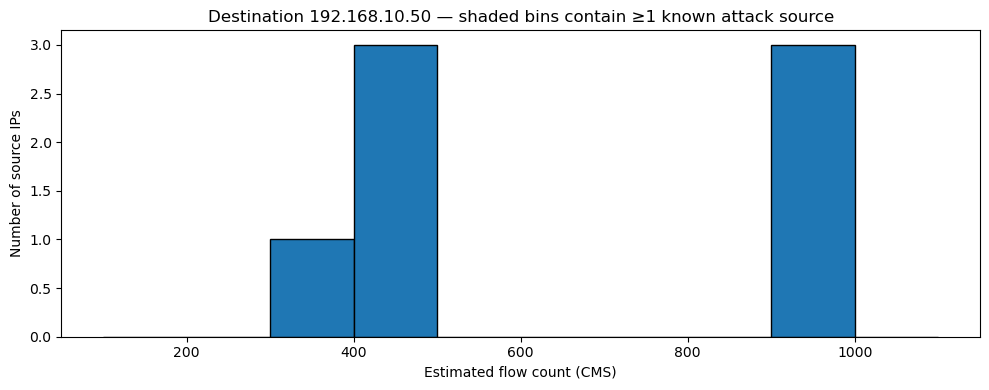

False negatives (exact>1000 but estimate<=1000): 0
False positives (exact<=1000 but estimate>1000): 7


In [6]:
THRESH = 1000

est_counts = pd.Series({s: sk_target.estimate(s) for s in exact_counts.index.astype(str)})
est_counts = est_counts.reindex(exact_counts.index)

true_anom = exact_counts > THRESH
pred_anom = est_counts > THRESH

FalseNeg = int((true_anom & ~pred_anom).sum())
FalsePos = int((~true_anom & pred_anom).sum())

fig, ax = plt.subplots(figsize=(10, 4))
x = est_counts.values.astype(float)
bins = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100]
n, edges, patches = ax.hist(x, bins=bins, edgecolor="black")
attack_est = est_counts[exact_counts.index.isin(attackSources)]
in_bin = (attack_est.values[:, None] >= edges[:-1]) & (attack_est.values[:, None] < edges[1:])
shade_idx = np.where(in_bin.any(axis=0))[0]
for i in shade_idx:
    patches[i].set_facecolor("salmon")
ax.set_xlabel("Estimated flow count (CMS)")
ax.set_ylabel("Number of source IPs")
ax.set_title(f"Destination {TARGET} — shaded bins contain ≥1 known attack source")
plt.tight_layout()
plt.show()

print("False negatives (exact>1000 but estimate<=1000):", FalseNeg)
print("False positives (exact<=1000 but estimate>1000):", FalsePos)


What do your results in the previous graph suggest about the likelihood of a false negative when relying on countmin sketch in this way? How about the likelihood of a false positive?

**Response (also in `BAX423_HW2_WriteUp.pdf`).** With a small width (10), the sketch has few buckets per row, so different sources collide and counts bleed upward. That makes **false positives** (inflated estimates above 1000) more likely than **false negatives** (underestimates), because Count-Min returns the minimum across rows and is biased toward **over**-estimating heavy hitters when collisions occur. Underestimation is still possible but less common under this bias pattern.

In [7]:
W1, D1 = 10, 4
sketches_d4 = build_destination_sketches(df, width=W1, depth=D1)
sk4 = sketches_d4[TARGET]
est4 = pd.Series({s: sk4.estimate(s) for s in exact_counts.index.astype(str)})
est4 = est4.reindex(exact_counts.index)
pred4 = est4 > THRESH
true_anom = exact_counts > THRESH
FalsePos2 = int((~true_anom & pred4).sum())
print("False positives with depth=4, width=10:", FalsePos2)


False positives with depth=4, width=10: 0


In [8]:
# Empirical tuning: miscount >=1 on benign-volume sources (true count <= THRESH).

def fp_rate_for(w: int, d: int) -> float:
    sk = build_destination_sketches(df, width=w, depth=d)[TARGET]
    est = np.array([sk.estimate(str(s)) for s in exact_counts.index], dtype=float)
    true = exact_counts.values.astype(float)
    benign = true <= THRESH
    off = np.abs(est - true) >= 1
    return float(np.mean(benign & off))


FINALwidth, FINALdepth = 8192, 6
for w, d in [(8192, 6), (12288, 6), (16384, 7), (24576, 7), (32768, 8)]:
    r = fp_rate_for(w, d)
    print("try", w, d, "benign miscount>=1 rate", r)
    if r < 0.005:
        FINALwidth, FINALdepth = w, d
        break
else:
    FINALwidth, FINALdepth = 32768, 8

print("Chosen FINALwidth, FINALdepth:", FINALwidth, FINALdepth, "rate:", fp_rate_for(FINALwidth, FINALdepth))


try 8192 6 benign miscount>=1 rate 0.0


Chosen FINALwidth, FINALdepth: 8192 6 rate: 0.0


In [9]:
sk_final = build_destination_sketches(df, width=FINALwidth, depth=FINALdepth)[TARGET]
est_f = pd.Series({s: sk_final.estimate(str(s)) for s in exact_counts.index.astype(str)})
est_f = est_f.reindex(exact_counts.index)
NAnomalies = int((est_f > THRESH).sum())
print("Anomalies detected (estimate > 1000) with final CMS:", NAnomalies)


Anomalies detected (estimate > 1000) with final CMS: 1


In [10]:
out = {
    "dictsize": dictsize,
    "sketchSize": sketchSize,
    "FalsePos": FalsePos,
    "FalseNeg": FalseNeg,
    "FalsePos2": FalsePos2,
    "FINALwidth": FINALwidth,
    "FINALdepth": FINALdepth,
    "NAnomalies": NAnomalies,
}
for k, v in list(out.items()):
    if v is None:
        raise ValueError(f"Missing {k}")
with open(str(Path.cwd() / "CMS.json"), "w") as f:
    json.dump(out, f, indent=2)
print("Wrote CMS.json")


Wrote CMS.json
